# 🎯 Atelier — Fine-tuning d'un détecteur d'objets YOLO

**Une introduction pratique au Deep Learning pour la vision par ordinateur**

> Ce notebook est la version **notebook** de l'application Streamlit
> `app.py`. Il est destiné aux participants qui savent lire et modifier
> du code Python. Les explications sont les mêmes, mais ici tout est
> **dans des cellules exécutables** que vous pouvez modifier librement.

---

## 📚 Plan de l'atelier

| # | Section | Concept clé |
|---|---------|-------------|
| 0 | Mise en route | Installer les dépendances, importer |
| 1 | Qu'est-ce que la détection d'objets ? | Classification vs détection vs segmentation |
| 2 | Les réseaux convolutifs (CNN) | Convolution, filtres, pooling |
| 3 | Le principe de YOLO | Une seule passe, grille, prédictions parallèles |
| 4 | Création du jeu de données | Générer des images synthétiques |
| 5 | Format des labels YOLO | `class xc yc w h` normalisé |
| 6 | Train / Validation / Test | Séparer les données, sur-apprentissage |
| 7 | Epoch, batch, loss | La mécanique de l'apprentissage |
| 8 | Entraînement du modèle | Lancer un vrai fine-tuning |
| 9 | Métriques d'évaluation | IoU, précision, rappel, mAP |
| 10 | Inférence | Détecter sur de nouvelles images |
| 11 | Récapitulatif | Synthèse et pistes pour aller plus loin |

## 🎓 Comment utiliser ce notebook

1. **Exécutez les cellules dans l'ordre** la première fois (Maj+Entrée).
2. **Cherchez les blocs `# 🔧 À toi de jouer`** : ce sont les endroits où vous
   êtes invité·e à modifier le code et à observer ce qui change.
3. **Les blocs `# 💡 Question`** sont des questions de réflexion (pas de code).
4. Le bloc d'entraînement (section 8) prend **~2 à 10 minutes** sur CPU
   selon les paramètres. Soyez patient·e.

## 📦 Bibliothèques utilisées

- **ultralytics** — l'implémentation officielle de YOLO
- **numpy**, **pandas** — calcul et manipulation de données
- **matplotlib**, **PIL** — visualisation
- **opencv-python** (`cv2`) — traitement d'images


---
## 0. Mise en route

### 0.1 Installation

⚠️ N'exécutez la cellule suivante **que si** vous n'avez pas déjà installé
les paquets. Sinon, sautez-la.

In [34]:
# Décommentez la ligne ci-dessous pour installer les dépendances
!pip install ultralytics pillow matplotlib numpy pandas opencv-python --quiet
print("Décommentez la commande pip si vous n'avez pas encore installé les paquets.")

Décommentez la commande pip si vous n'avez pas encore installé les paquets.


### 0.2 Imports

Tout ce dont on aura besoin dans ce notebook.

In [35]:
import os
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

# Pour rendre les graphiques plus nets
plt.rcParams['figure.dpi'] = 90

# Pour la reproductibilité
RNG_SEED = 42
np.random.seed(RNG_SEED)

print(f"NumPy   {np.__version__}")
print(f"OpenCV  {cv2.__version__}")
print(f"Pandas  {pd.__version__}")

NumPy   1.24.4
OpenCV  4.6.0
Pandas  1.4.4


### 0.3 Constantes partagées

On définit ici quelques constantes utilisées dans plusieurs sections.

In [36]:
# Dossiers pour le jeu de données et l'entraînement
ROOT = Path.cwd()
DATASET_PATH = ROOT / "mini_dataset"
RUNS_PATH = ROOT / "yolo_finetuning"
RUN_NAME = "shape_detector_atelier"

# Les 3 classes que notre détecteur va apprendre à reconnaître
CLASS_NAMES = {0: "rectangle", 1: "cercle", 2: "triangle"}

# Le modèle pré-entraîné le plus petit disponible chez Ultralytics
# (~2,6 M paramètres, idéal pour entraîner sur CPU)
PRETRAINED_MODEL = "yolo11n.pt"

print(f"Dossier racine    : {ROOT}")
print(f"Jeu de données    : {DATASET_PATH}")
print(f"Modèle de départ  : {PRETRAINED_MODEL}")

Dossier racine    : /Users/chateau/Enseignement/MachineLearning/DeepLearning/Tds/practical_yolo
Jeu de données    : /Users/chateau/Enseignement/MachineLearning/DeepLearning/Tds/practical_yolo/mini_dataset
Modèle de départ  : yolo11n.pt


---
## 1. Qu'est-ce que la détection d'objets ?

En vision par ordinateur, on distingue **trois grandes tâches** :

| Tâche | Question | Sortie |
|-------|----------|--------|
| 🏷️ **Classification** | « Qu'y a-t-il sur l'image ? » | Une étiquette pour l'image |
| 🎯 **Détection** | « Quoi, *et où* ? » | Étiquette + boîte par objet |
| 🧩 **Segmentation** | « À quel objet appartient chaque pixel ? » | Masque pixel par pixel |

YOLO se situe dans la deuxième catégorie : la **détection**.

### 💡 Pourquoi la détection est-elle plus difficile ?

Parce que le modèle doit produire **plusieurs informations** par image :
- le **nombre** d'objets (qui varie d'une image à l'autre)
- la **classe** de chaque objet
- la **position** (x, y, largeur, hauteur) de chaque objet
- un **score de confiance** par détection


/var/folders/x5/bcynmv8s67bczy9pg8gblp3m0000gp/T/ipykernel_72386/3354719459.py:28: UserWarning: Glyph 127991 (\N{LABEL}) missing from current font.
  plt.tight_layout()
/var/folders/x5/bcynmv8s67bczy9pg8gblp3m0000gp/T/ipykernel_72386/3354719459.py:28: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
/var/folders/x5/bcynmv8s67bczy9pg8gblp3m0000gp/T/ipykernel_72386/3354719459.py:28: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from current font.
  plt.tight_layout()
/Users/chateau/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127991 (\N{LABEL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chateau/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chateau/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:15

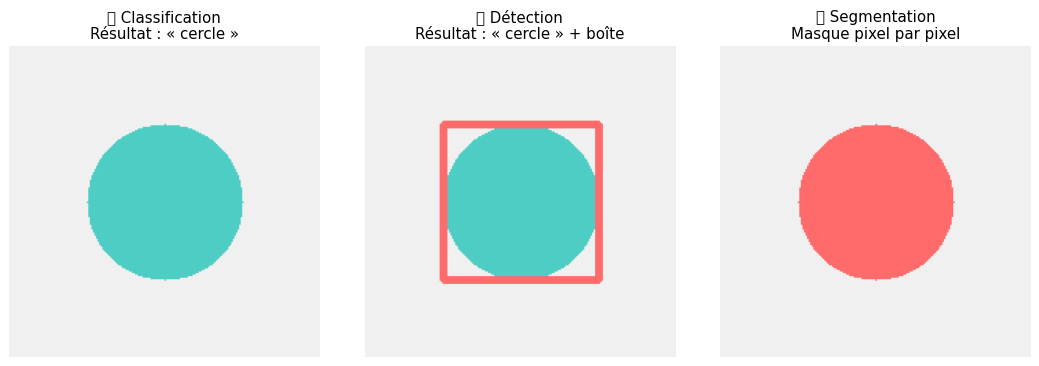

In [37]:
# Petite illustration : classification vs détection vs segmentation
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# ----- Classification : juste l'image -----
img1 = np.ones((200, 200, 3), dtype=np.uint8) * 240
cv2.circle(img1, (100, 100), 50, (78, 205, 196), -1)
axes[0].imshow(img1)
axes[0].set_title("🏷️ Classification\nRésultat : « cercle »")
axes[0].axis('off')

# ----- Détection : image + boîte -----
img2 = np.ones((200, 200, 3), dtype=np.uint8) * 240
cv2.circle(img2, (100, 100), 50, (78, 205, 196), -1)
cv2.rectangle(img2, (50, 50), (150, 150), (255, 107, 107), 3)
axes[1].imshow(img2)
axes[1].set_title("🎯 Détection\nRésultat : « cercle » + boîte")
axes[1].axis('off')

# ----- Segmentation : masque pixel par pixel -----
img3 = np.ones((200, 200, 3), dtype=np.uint8) * 240
mask = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(mask, (100, 100), 50, 255, -1)
img3[mask > 0] = (255, 107, 107)
axes[2].imshow(img3)
axes[2].set_title("🧩 Segmentation\nMasque pixel par pixel")
axes[2].axis('off')

plt.tight_layout()
plt.show()

**💡 Question** : si vous voulez compter combien de personnes traversent
une rue, quelle tâche choisissez-vous ? Et si vous voulez mesurer leur
distance par rapport à la caméra ?

---
## 2. Les réseaux convolutifs (CNN)

Avant d'attaquer YOLO, faisons un détour par les **CNN** (*Convolutional
Neural Networks* — réseaux de neurones convolutifs), car **YOLO est avant
tout un grand CNN**.

### 2.1 Pourquoi pas un réseau de neurones classique ?

Une image 320×320 en couleur, c'est **307 200 pixels** (320 × 320 × 3 canaux RVB).

Si on connectait tous ces pixels à un réseau « dense » (chaque pixel relié
à chaque neurone), on aurait :

- **des millions de poids** dès la première couche
- **aucune notion de voisinage** : le modèle ne saurait pas qu'un bord
  s'étend sur plusieurs pixels contigus
- **aucune invariance par translation** : il apprendrait *séparément* à
  reconnaître un objet en haut à gauche et le même objet en bas à droite

Les CNN règlent ces problèmes en **exploitant la structure 2D** des images.

### 2.2 La brique de base : la convolution

Une **convolution** consiste à faire glisser un petit **filtre** (par
exemple une matrice 3×3) sur toute l'image. À chaque position, on
multiplie le filtre par la zone d'image correspondante et on additionne.
Le résultat est une **carte d'activation** qui indique, en chaque point,
*à quel point cette zone ressemble au motif* du filtre.

**Avantages décisifs** :
- **peu de paramètres** : un filtre 3×3 = seulement 9 poids, partagés sur
  toute l'image
- **détection locale** : chaque sortie ne dépend que d'une petite zone
- **invariance par translation** : le même filtre détecte le motif partout

Manipulons ça !

In [38]:
# Quelques filtres classiques 3x3 (qu'un CNN pourrait apprendre tout seul)
kernels = {
    "Identité":              np.array([[ 0,  0,  0], [ 0,  1,  0], [ 0,  0,  0]], dtype=np.float32),
    "Contours (Laplacien)":  np.array([[ 0, -1,  0], [-1,  4, -1], [ 0, -1,  0]], dtype=np.float32),
    "Contours verticaux":    np.array([[-1,  0,  1], [-2,  0,  2], [-1,  0,  1]], dtype=np.float32),
    "Contours horizontaux":  np.array([[-1, -2, -1], [ 0,  0,  0], [ 1,  2,  1]], dtype=np.float32),
    "Flou (moyenne)":        np.ones((3, 3), dtype=np.float32) / 9.0,
    "Accentuation (sharpen)":np.array([[ 0, -1,  0], [-1,  5, -1], [ 0, -1,  0]], dtype=np.float32),
}

# Affichons-les sous forme de tableau
for name, k in kernels.items():
    print(f"--- {name} ---")
    print(k)
    print()

--- Identité ---
[[          0           0           0]
 [          0           1           0]
 [          0           0           0]]

--- Contours (Laplacien) ---
[[          0          -1           0]
 [         -1           4          -1]
 [          0          -1           0]]

--- Contours verticaux ---
[[         -1           0           1]
 [         -2           0           2]
 [         -1           0           1]]

--- Contours horizontaux ---
[[         -1          -2          -1]
 [          0           0           0]
 [          1           2           1]]

--- Flou (moyenne) ---
[[    0.11111     0.11111     0.11111]
 [    0.11111     0.11111     0.11111]
 [    0.11111     0.11111     0.11111]]

--- Accentuation (sharpen) ---
[[          0          -1           0]
 [         -1           5          -1]
 [          0          -1           0]]



On a besoin d'une image pour tester ces filtres. On va construire une
fonction qui génère des images synthétiques de formes — on s'en resservira
abondamment dans la section 4. Lisez la fonction ci-dessous, c'est la
brique centrale de tout le tutoriel.

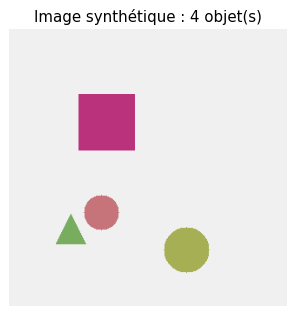

Labels (class_id, xc, yc, w, h) :
  cercle     → (0.637, 0.797, 0.166, 0.166)
  rectangle  → (0.350, 0.338, 0.200, 0.200)
  triangle   → (0.222, 0.722, 0.106, 0.106)
  cercle     → (0.331, 0.662, 0.125, 0.125)


In [39]:
def draw_shape(img, shape_type, x_center, y_center, size, color):
    '''Dessine une forme sur `img` et renvoie la bbox normalisée (xc, yc, w, h).

    Args:
        img: image numpy HxWx3 (modifiée sur place)
        shape_type: 0=rectangle, 1=cercle, 2=triangle
        x_center, y_center: centre en pixels
        size: taille de la forme en pixels
        color: tuple BGR
    '''
    h, w = img.shape[:2]
    if shape_type == 0:  # Rectangle
        x1 = max(0, x_center - size // 2)
        y1 = max(0, y_center - size // 2)
        x2 = min(w, x_center + size // 2)
        y2 = min(h, y_center + size // 2)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, -1)
        return (x1 + x2) / 2 / w, (y1 + y2) / 2 / h, (x2 - x1) / w, (y2 - y1) / h
    if shape_type == 1:  # Cercle
        cv2.circle(img, (x_center, y_center), size // 2, color, -1)
        return x_center / w, y_center / h, size / w, size / h
    # Triangle
    pts = np.array([
        [x_center,             y_center - size // 2],
        [x_center - size // 2, y_center + size // 2],
        [x_center + size // 2, y_center + size // 2],
    ], np.int32)
    cv2.fillPoly(img, [pts], color)
    return x_center / w, y_center / h, size / w, size / h


def make_synthetic_image(seed, n_objects_range=(1, 4), img_size=320):
    '''Crée une image synthétique aléatoire. Renvoie (image, liste de labels).

    Chaque label est un tuple (class_id, x_center, y_center, width, height)
    avec les coordonnées normalisées entre 0 et 1.
    '''
    rng = np.random.default_rng(seed)
    img = np.ones((img_size, img_size, 3), dtype=np.uint8) * 240
    labels = []
    n_objects = int(rng.integers(n_objects_range[0], n_objects_range[1] + 1))
    for _ in range(n_objects):
        shape_type = int(rng.integers(0, 3))
        x_c = int(rng.integers(40, img_size - 40))
        y_c = int(rng.integers(40, img_size - 40))
        size = int(rng.integers(30, 70))
        color = tuple(int(v) for v in rng.integers(50, 200, 3))
        bbox = draw_shape(img, shape_type, x_c, y_c, size, color)
        labels.append((shape_type, *bbox))
    return img, labels


# Test : une image avec sa liste de labels
demo_img, demo_labels = make_synthetic_image(seed=7, n_objects_range=(2, 4))
plt.figure(figsize=(4, 4))
plt.imshow(demo_img)
plt.title(f"Image synthétique : {len(demo_labels)} objet(s)")
plt.axis('off')
plt.show()

print("Labels (class_id, xc, yc, w, h) :")
for lbl in demo_labels:
    print(f"  {CLASS_NAMES[lbl[0]]:10s} → ({lbl[1]:.3f}, {lbl[2]:.3f}, {lbl[3]:.3f}, {lbl[4]:.3f})")

Appliquons maintenant les filtres à cette image.

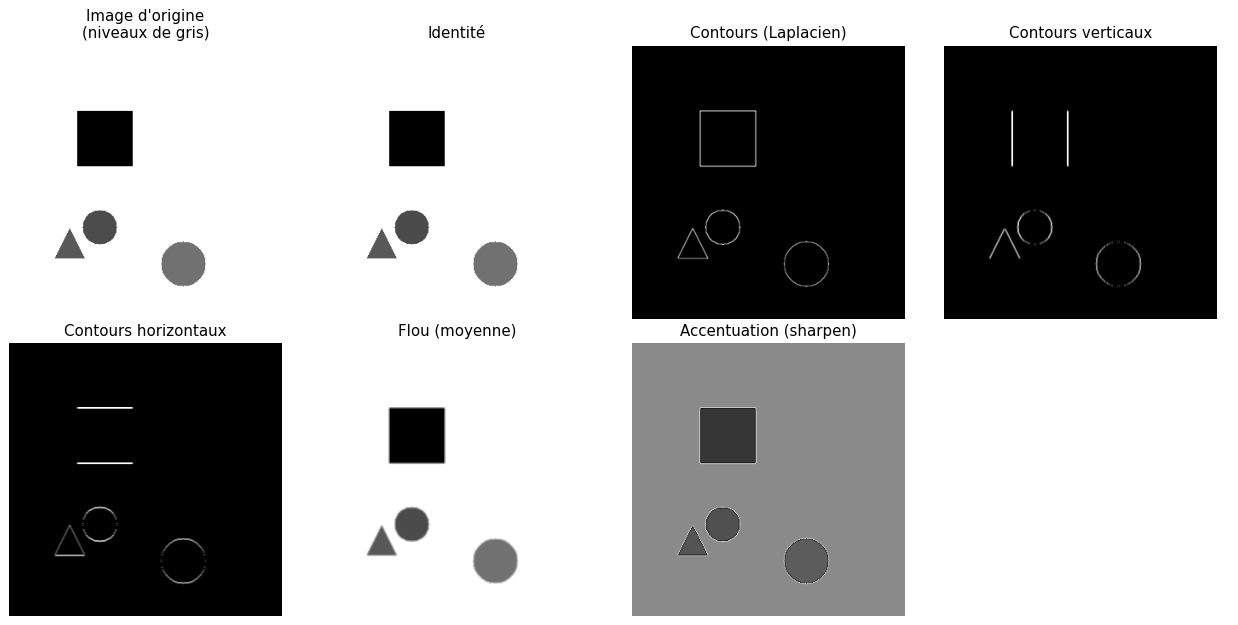

In [40]:
# Convertir l'image en niveaux de gris pour la convolution
gray = cv2.cvtColor(demo_img, cv2.COLOR_RGB2GRAY)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

# Première case : image d'origine
axes[0].imshow(gray, cmap='gray')
axes[0].set_title("Image d'origine\n(niveaux de gris)")
axes[0].axis('off')

# Cases suivantes : un filtre chacun
for i, (name, k) in enumerate(kernels.items(), start=1):
    filtered = cv2.filter2D(gray, ddepth=cv2.CV_32F, kernel=k)
    # Normaliser pour affichage
    abs_f = np.abs(filtered)
    norm = (abs_f / (abs_f.max() + 1e-9) * 255).astype(np.uint8)
    axes[i].imshow(norm, cmap='gray')
    axes[i].set_title(name)
    axes[i].axis('off')

# Cacher la dernière case (8 cases, 7 utilisées)
axes[7].axis('off')

plt.tight_layout()
plt.show()

**👀 Observation** : chaque filtre **met en évidence** un type de motif
particulier. Le Laplacien fait ressortir **tous** les contours, Sobel X
uniquement les **contours verticaux**, etc.

🎯 **L'idée centrale** : **un CNN apprend automatiquement des centaines de
filtres** comme ceux-ci ; on ne les écrit jamais à la main.

### 🔧 À toi de jouer

Modifiez les valeurs du filtre ci-dessous et observez l'effet. Quelques
idées :
- un filtre avec **uniquement des 1** au milieu → effet de quoi ?
- un filtre **anti-symétrique** vertical → équivalent à quel filtre connu ?
- un filtre **gaussien 3×3** (centre fort, voisins moyens, coins faibles)

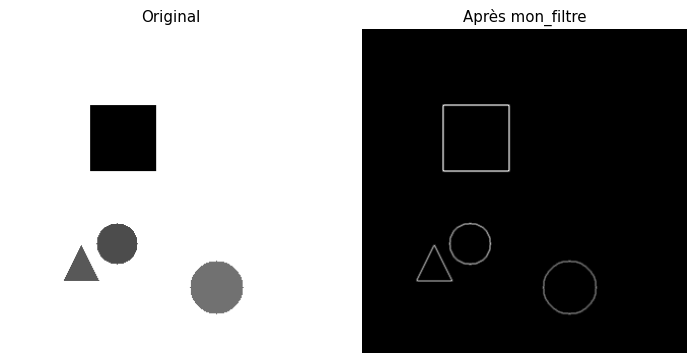

Filtre utilisé :
[[         -1          -1          -1]
 [         -1           8          -1]
 [         -1          -1          -1]]


In [41]:
# 🔧 À toi de jouer — modifie ces valeurs, ré-exécute la cellule
mon_filtre = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
], dtype=np.float32)

result = cv2.filter2D(gray, ddepth=cv2.CV_32F, kernel=mon_filtre)
abs_r = np.abs(result)
norm = (abs_r / (abs_r.max() + 1e-9) * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(gray, cmap='gray'); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(norm, cmap='gray'); axes[1].set_title("Après mon_filtre"); axes[1].axis('off')
plt.tight_layout()
plt.show()
print("Filtre utilisé :")
print(mon_filtre)

### 2.3 Le pooling — réduire la taille

Entre les couches de convolution, on intercale du **pooling**
(en général **max-pooling 2×2**), qui :

- **divise par 2** la hauteur et la largeur de la carte d'activation
- **rend le réseau plus robuste** aux petits décalages
- **réduit le coût** des couches suivantes

Voici comment ça marche :

In [42]:
def max_pool_2x2(matrix):
    '''Applique un max-pooling 2x2 à une matrice 2D.'''
    h, w = matrix.shape
    out = np.zeros((h // 2, w // 2), dtype=matrix.dtype)
    for i in range(h // 2):
        for j in range(w // 2):
            out[i, j] = matrix[2*i:2*i+2, 2*j:2*j+2].max()
    return out


avant = np.array([
    [3, 1, 4, 1],
    [5, 9, 2, 6],
    [5, 3, 5, 8],
    [9, 7, 9, 3],
])
apres = max_pool_2x2(avant)

print("Avant pooling (4×4) :")
print(avant)
print()
print("Après max-pool 2×2 :")
print(apres)
print()
print("Explication : on prend le max de chaque bloc 2×2.")
print(f"  Bloc en haut à gauche : max(3, 1, 5, 9) = {apres[0, 0]}")
print(f"  Bloc en haut à droite : max(4, 1, 2, 6) = {apres[0, 1]}")

Avant pooling (4×4) :
[[3 1 4 1]
 [5 9 2 6]
 [5 3 5 8]
 [9 7 9 3]]

Après max-pool 2×2 :
[[9 6]
 [9 9]]

Explication : on prend le max de chaque bloc 2×2.
  Bloc en haut à gauche : max(3, 1, 5, 9) = 9
  Bloc en haut à droite : max(4, 1, 2, 6) = 6


### 2.4 Architecture globale d'un CNN

Un CNN typique enchaîne ces blocs **plusieurs fois** :

```
Image
   ↓
[Convolution + activation (ReLU)]   ← détecter des motifs
[Pooling]                            ← réduire la taille
   ↓
[Convolution + ReLU]                 ← motifs plus complexes
[Pooling]
   ↓
... (5 à 50 fois selon le réseau)
   ↓
[Tête spécifique à la tâche]         ← classification, détection, …
```

À chaque étage, la carte devient **plus petite spatialement** mais
**plus riche sémantiquement** (plus de canaux, chacun contenant une
caractéristique différente).

**Résultat empirique observé dans tous les CNN visuels** :
- 🟦 **Premières couches** → contours, lignes, dégradés
- 🟨 **Couches intermédiaires** → textures, coins, petits motifs
- 🟥 **Couches profondes** → parties d'objets, puis objets entiers

### 2.5 Lien avec YOLO

YOLO est composé de **deux parties** :

1. **Un backbone CNN** (la « colonne vertébrale ») qui extrait les
   caractéristiques hiérarchiques.
2. **Une tête de détection** qui prédit boîtes, classes et confiances à
   partir de ces caractéristiques.

C'est ce qu'on voit dans la **section suivante**.

> 💡 **À retenir**
> - Un **CNN** apprend des **filtres** à appliquer sur l'image.
> - **Convolution + pooling** empilés → **hiérarchie** : contours → textures → objets.
> - **YOLO = un CNN (backbone) + une tête de détection**.

---
## 3. Le principe de YOLO

**YOLO** signifie *You Only Look Once* — « tu ne regardes qu'une seule fois ».

**Avant YOLO**, les détecteurs (R-CNN, Fast-RCNN…) procédaient en **deux
étapes** :
1. proposer des centaines de **régions candidates** dans l'image
2. **classifier** chacune séparément

C'était lent. YOLO change le paradigme : **une seule passe** sur l'image
suffit pour prédire **simultanément** les boîtes et les classes.

### 3.1 Le principe de la grille

YOLO découpe l'image en une **grille** (par exemple 7×7 ou 13×13). Pour
chaque cellule, le modèle prédit en parallèle :

- 📦 plusieurs **boîtes candidates** (position + taille)
- 🎯 un **score de confiance** par boîte (« y a-t-il un objet ici ? »)
- 🏷️ une **distribution de probabilités** sur les classes

Tous ces nombres sortent **en parallèle** d'un seul passage avant.

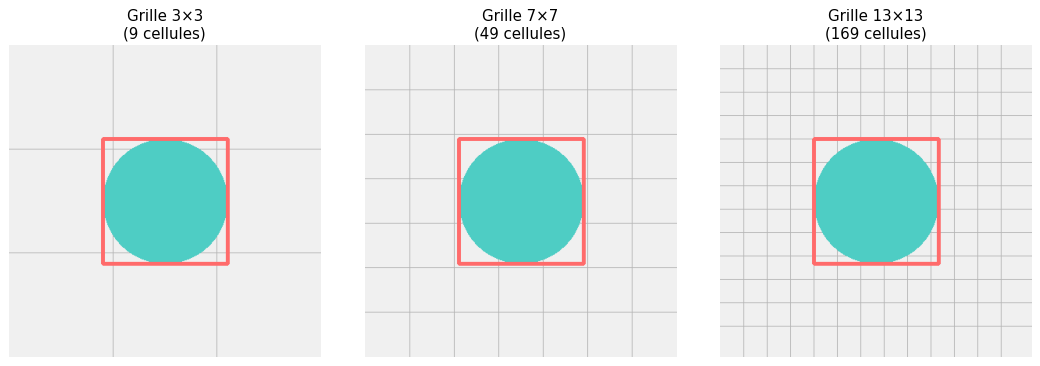

In [43]:
# Visualisons le concept de la grille
def draw_yolo_grid(grid_size=7, img_size=400):
    img = np.ones((img_size, img_size, 3), dtype=np.uint8) * 240
    cell = img_size // grid_size
    # Lignes de la grille
    for i in range(1, grid_size):
        cv2.line(img, (i * cell, 0), (i * cell, img_size), (180, 180, 180), 1)
        cv2.line(img, (0, i * cell), (img_size, i * cell), (180, 180, 180), 1)
    # Un objet et sa boîte de détection
    cv2.circle(img, (img_size // 2, img_size // 2), img_size // 5, (78, 205, 196), -1)
    cv2.rectangle(img,
                  (img_size // 2 - img_size // 5, img_size // 2 - img_size // 5),
                  (img_size // 2 + img_size // 5, img_size // 2 + img_size // 5),
                  (255, 107, 107), 3)
    return img


fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, gs in zip(axes, [3, 7, 13]):
    ax.imshow(draw_yolo_grid(gs))
    ax.set_title(f"Grille {gs}×{gs}\n({gs*gs} cellules)")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [44]:
# Combien de prédictions brutes par image ?
# Pour une grille SxS, avec B boîtes par cellule et C classes :
#   nombre de sorties = S * S * (B * 5 + C)
# (5 = 4 coordonnées + 1 score de confiance)

S, B, C = 13, 3, 3  # grille 13x13, 3 boîtes par cellule, 3 classes
n_predictions = S * S * (B * 5 + C)
print(f"Avec S={S}, B={B} boîtes par cellule, C={C} classes :")
print(f"  → {n_predictions} prédictions brutes par image")
print()
print("La plupart seront éliminées :")
print(" 1. par un SEUIL DE CONFIANCE (typiquement 0.25)")
print(" 2. par la NMS (Non-Maximum Suppression) qui fusionne les boîtes "
      "qui se chevauchent trop")

Avec S=13, B=3 boîtes par cellule, C=3 classes :
  → 3042 prédictions brutes par image

La plupart seront éliminées :
 1. par un SEUIL DE CONFIANCE (typiquement 0.25)
 2. par la NMS (Non-Maximum Suppression) qui fusionne les boîtes qui se chevauchent trop


### 3.2 Pourquoi YOLO est rapide

- **Une seule passe** dans le réseau, contre des centaines pour R-CNN
- **Architecture entièrement convolutionnelle** : très efficace sur GPU
- **Petites variantes** disponibles (YOLO11n = 2,6 M paramètres)

| Modèle | Paramètres | Vitesse CPU |
|--------|-----------|-------------|
| **YOLO11n (nano)** | **2,6 M** | **⚡⚡⚡⚡ (le plus rapide)** |
| YOLOv8n (nano) | 3,2 M | ⚡⚡⚡ |
| YOLO11s (small) | 9,4 M | ⚡⚡ |
| YOLO11m (medium) | 20,1 M | ⚡ |
| YOLO11l (large) | 25,3 M | 🐌 |

On utilisera **YOLO11n** — le plus petit modèle disponible.

**💡 Question** : si vous deviez détecter des objets sur un téléphone
embarqué avec peu de RAM, lequel choisiriez-vous ? Et pour un serveur GPU
avec besoin de précision maximale ?

---
## 4. Création du jeu de données

Un modèle de détection apprend à partir **d'exemples** : des images
accompagnées de leurs **annotations** (boîtes + classes).

Pour ce tutoriel, on **génère** des images synthétiques avec les
fonctions définies en section 2. Avantage : on a immédiatement les
labels exacts.

### 4.1 Structure de dossier attendue par YOLO

```
mini_dataset/
├── images/
│   ├── train/   ← images d'entraînement
│   └── val/     ← images de validation
├── labels/
│   ├── train/   ← un .txt par image, même nom
│   └── val/
└── data.yaml    ← fichier de configuration
```

Chaque image `img_042.jpg` a un fichier `img_042.txt` avec ses labels.

In [45]:
# Création des dossiers
for split in ("train", "val"):
    (DATASET_PATH / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_PATH / "labels" / split).mkdir(parents=True, exist_ok=True)

print(f"✓ Structure créée dans : {DATASET_PATH.absolute()}")
for path in sorted(DATASET_PATH.rglob("*")):
    if path.is_dir():
        print(f"  📁 {path.relative_to(DATASET_PATH)}")

✓ Structure créée dans : /Users/chateau/Enseignement/MachineLearning/DeepLearning/Tds/practical_yolo/mini_dataset
  📁 images
  📁 images/train
  📁 images/val
  📁 labels
  📁 labels/train
  📁 labels/val


### 4.2 Aperçu de quelques images

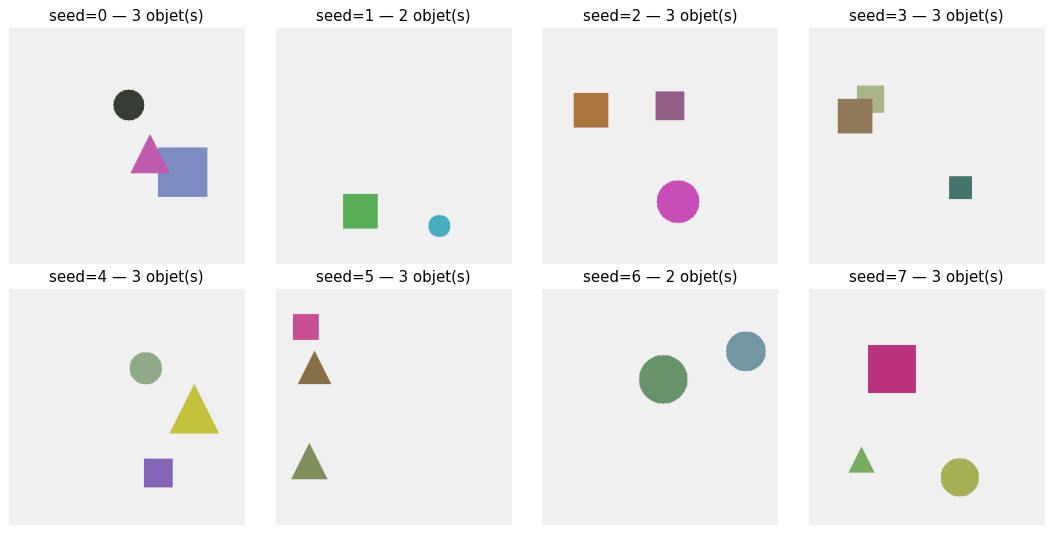

In [46]:
# Affichons un échantillon
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    img, lbls = make_synthetic_image(seed=i, n_objects_range=(1, 3))
    ax.imshow(img)
    ax.set_title(f"seed={i} — {len(lbls)} objet(s)")
    ax.axis('off')
plt.tight_layout()
plt.show()

### 4.3 Génération complète du dataset

On écrit les images et leurs labels sur disque. **Modifiez les paramètres
ci-dessous** si vous voulez un dataset plus gros ou plus complexe.

In [47]:
# 🔧 Paramètres à modifier
N_TRAIN = 40                  # nombre d'images d'entraînement
N_VAL = 10                    # nombre d'images de validation
OBJECTS_PER_IMAGE = (1, 3)    # min et max d'objets par image
IMG_SIZE = 320                # taille des images en pixels


def save_split(n_images, seed_offset, split_name):
    '''Génère et sauvegarde n_images dans le split donné.'''
    n_objects_total = 0
    for i in range(n_images):
        img, labels = make_synthetic_image(
            seed=seed_offset + i,
            n_objects_range=OBJECTS_PER_IMAGE,
            img_size=IMG_SIZE,
        )
        # Sauvegarde de l'image
        img_path = DATASET_PATH / "images" / split_name / f"img_{i:03d}.jpg"
        Image.fromarray(img).save(img_path)
        # Sauvegarde des labels au format YOLO : un objet par ligne
        lbl_path = DATASET_PATH / "labels" / split_name / f"img_{i:03d}.txt"
        with open(lbl_path, "w") as f:
            for c, xc, yc, w, h in labels:
                f.write(f"{c} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")
        n_objects_total += len(labels)
    return n_objects_total


print("Génération du jeu d'entraînement...")
n_train_obj = save_split(N_TRAIN, seed_offset=0, split_name="train")

print("Génération du jeu de validation...")
n_val_obj = save_split(N_VAL, seed_offset=1000, split_name="val")

print()
print(f"✅ Dataset prêt : {N_TRAIN} images train ({n_train_obj} objets), "
      f"{N_VAL} images val ({n_val_obj} objets)")

Génération du jeu d'entraînement...
Génération du jeu de validation...

✅ Dataset prêt : 40 images train (89 objets), 10 images val (20 objets)


### 4.4 Fichier de configuration `data.yaml`

YOLO a besoin d'un fichier YAML qui décrit où trouver les images et
quelles sont les classes.

In [48]:
yaml_content = f'''# Configuration du jeu de données pour YOLO
path: {DATASET_PATH.absolute()}  # chemin absolu vers la racine
train: images/train  # chemin relatif vers les images d'entraînement
val: images/val      # chemin relatif vers les images de validation

# Noms des classes (ID : nom)
names:
  0: rectangle
  1: cercle
  2: triangle
'''

yaml_path = DATASET_PATH / "data.yaml"
yaml_path.write_text(yaml_content)

print(f"✓ Fichier écrit : {yaml_path}")
print()
print(yaml_content)

✓ Fichier écrit : /Users/chateau/Enseignement/MachineLearning/DeepLearning/Tds/practical_yolo/mini_dataset/data.yaml

# Configuration du jeu de données pour YOLO
path: /Users/chateau/Enseignement/MachineLearning/DeepLearning/Tds/practical_yolo/mini_dataset  # chemin absolu vers la racine
train: images/train  # chemin relatif vers les images d'entraînement
val: images/val      # chemin relatif vers les images de validation

# Noms des classes (ID : nom)
names:
  0: rectangle
  1: cercle
  2: triangle



### 🎓 En projet réel

Vous remplacerez cette génération par :

1. la **collecte de vraies photos** (téléphone, scrap web, capteurs…)
2. l'**annotation manuelle** avec un outil comme :
   - [LabelImg](https://github.com/tzutalin/labelImg) — desktop, gratuit
   - [Roboflow](https://roboflow.com/) — web, gratuit jusqu'à 10k images
   - [CVAT](https://www.cvat.ai/) — pour les équipes
3. l'**export au format YOLO** (le même format qu'ici)

**💡 Bonnes pratiques** :
- au moins **50 à 100 images par classe**
- **variété** : angles, éclairages, arrière-plans, échelles
- **équilibre** : éviter qu'une classe domine massivement les autres

---
## 5. Format des labels YOLO

Pour chaque image, YOLO attend un fichier `.txt` du même nom contenant
**une ligne par objet** :

```
class_id x_center y_center width height
```

Les 4 coordonnées sont **normalisées entre 0 et 1**, c'est-à-dire
exprimées comme une **fraction** de la taille de l'image. Ainsi, le
même label fonctionne quelle que soit la résolution.

### 5.1 Formules

Pour une image de **W** pixels de large et **H** pixels de haut, avec
un objet dont la boîte va de $(x_1, y_1)$ à $(x_2, y_2)$ :

$$x_{center} = \frac{(x_1 + x_2) / 2}{W} \quad y_{center} = \frac{(y_1 + y_2) / 2}{H}$$

$$width = \frac{x_2 - x_1}{W} \quad height = \frac{y_2 - y_1}{H}$$

In [49]:
# Calculons un label en détail
W, H = 320, 320                # taille de l'image
x1, y1 = 60, 80                # coin haut-gauche de la boîte en pixels
x2, y2 = 220, 240              # coin bas-droit de la boîte en pixels
class_id = 1                   # 0=rectangle, 1=cercle, 2=triangle

# Conversion en format YOLO normalisé
xc = (x1 + x2) / 2 / W
yc = (y1 + y2) / 2 / H
w  = (x2 - x1) / W
h  = (y2 - y1) / H

print(f"Image          : {W}×{H} px")
print(f"Boîte en pixels: ({x1}, {y1}) → ({x2}, {y2})")
print()
print("Calcul du label YOLO :")
print(f"  x_center = ({x1}+{x2})/2 / {W} = {(x1+x2)/2}/{W} = {xc:.6f}")
print(f"  y_center = ({y1}+{y2})/2 / {H} = {(y1+y2)/2}/{H} = {yc:.6f}")
print(f"  width    = ({x2}-{x1})/{W} = {x2-x1}/{W} = {w:.6f}")
print(f"  height   = ({y2}-{y1})/{H} = {y2-y1}/{H} = {h:.6f}")
print()
print(f"📋 Label final :  {class_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

Image          : 320×320 px
Boîte en pixels: (60, 80) → (220, 240)

Calcul du label YOLO :
  x_center = (60+220)/2 / 320 = 140.0/320 = 0.437500
  y_center = (80+240)/2 / 320 = 160.0/320 = 0.500000
  width    = (220-60)/320 = 160/320 = 0.500000
  height   = (240-80)/320 = 160/320 = 0.500000

📋 Label final :  1 0.437500 0.500000 0.500000 0.500000


### 5.2 Vérification visuelle

Vérifions qu'on retombe bien sur la bonne boîte en faisant l'opération
**inverse** (label → pixels).

Boîte originale       : (60,      80,      220,      240)
Boîte reconstruite    : (60, 80, 220, 240)


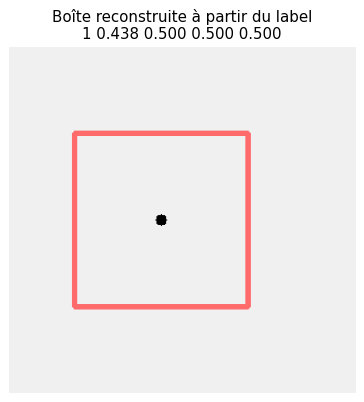

In [50]:
def bbox_yolo_to_pixels(xc, yc, w, h, img_w, img_h):
    '''Convertit (xc, yc, w, h) normalisés vers (x1, y1, x2, y2) en pixels.'''
    x1 = int((xc - w / 2) * img_w)
    y1 = int((yc - h / 2) * img_h)
    x2 = int((xc + w / 2) * img_w)
    y2 = int((yc + h / 2) * img_h)
    return x1, y1, x2, y2


# Reconstruisons la boîte à partir du label
x1_back, y1_back, x2_back, y2_back = bbox_yolo_to_pixels(xc, yc, w, h, W, H)
print(f"Boîte originale       : ({x1},      {y1},      {x2},      {y2})")
print(f"Boîte reconstruite    : ({x1_back}, {y1_back}, {x2_back}, {y2_back})")

# Affichage
img = np.ones((H, W, 3), dtype=np.uint8) * 240
cv2.rectangle(img, (x1_back, y1_back), (x2_back, y2_back), (255, 107, 107), 3)
cv2.circle(img, (int((x1_back+x2_back)/2), int((y1_back+y2_back)/2)), 5, (0, 0, 0), -1)
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Boîte reconstruite à partir du label\n"
          f"{class_id} {xc:.3f} {yc:.3f} {w:.3f} {h:.3f}")
plt.axis('off')
plt.show()

### 5.3 Inspectons un vrai fichier de label

Contenu de img_000.txt :
1 0.506250 0.325000 0.131250 0.131250
0 0.734375 0.609375 0.206250 0.206250
2 0.596875 0.531250 0.162500 0.162500



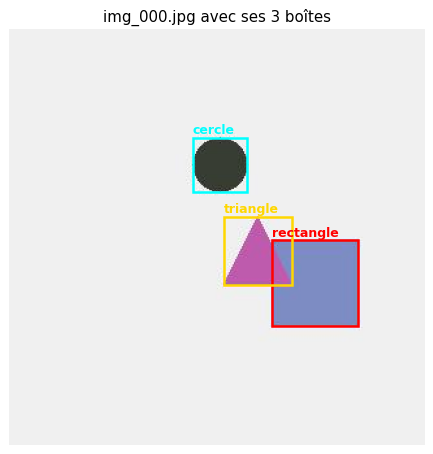

In [51]:
# Affichons le contenu du premier fichier de label généré en section 4
first_label_file = DATASET_PATH / "labels" / "train" / "img_000.txt"
first_image_file = DATASET_PATH / "images" / "train" / "img_000.jpg"

print(f"Contenu de {first_label_file.name} :")
print(first_label_file.read_text())

# Visualisons l'image avec ses boîtes superposées
img = np.array(Image.open(first_image_file))
H, W = img.shape[:2]
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
for line in first_label_file.read_text().strip().split('\n'):
    parts = line.split()
    cls = int(parts[0])
    xc, yc, w, h = map(float, parts[1:])
    x1, y1, x2, y2 = bbox_yolo_to_pixels(xc, yc, w, h, W, H)
    color = {0: 'red', 1: 'cyan', 2: 'gold'}[cls]
    ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                fill=False, edgecolor=color, linewidth=2))
    ax.text(x1, y1-3, CLASS_NAMES[cls], color=color, fontweight='bold')
ax.set_title(f"{first_image_file.name} avec ses {len(first_label_file.read_text().strip().splitlines())} boîtes")
ax.axis('off')
plt.show()

### ⚠️ Pièges courants à éviter

- ne pas confondre `(x1, y1, x2, y2)` avec `(x_center, y_center, w, h)`
- oublier de **normaliser** par la taille de l'image
- décaler les `class_id` (YOLO commence à **0**, pas à 1)
- inverser X et Y (les images ont l'origine en **haut à gauche**)

**🔧 À toi de jouer** : modifiez les valeurs dans le calcul de label
ci-dessus (`x1, y1, x2, y2, class_id`) et observez comment le label
change. Que se passe-t-il si vous mettez `x2 < x1` ?

---
## 6. Train / Validation / Test

On ne donne **jamais** toutes ses données au modèle pour l'entraînement.
On les sépare en plusieurs ensembles ayant chacun un rôle précis :

| Ensemble | Rôle | Proportion typique |
|----------|------|--------------------|
| **Train** | Le modèle **apprend** dessus | 70–80 % |
| **Validation** | Régler les hyperparamètres, suivre la progression | 10–20 % |
| **Test** | Mesurer les performances **finales** sur des données **jamais vues** | 10–20 % |

Dans ce tutoriel on n'utilise que **train + val** pour simplifier, mais
en projet réel un set de test est indispensable.

### 6.1 Visualisation des splits

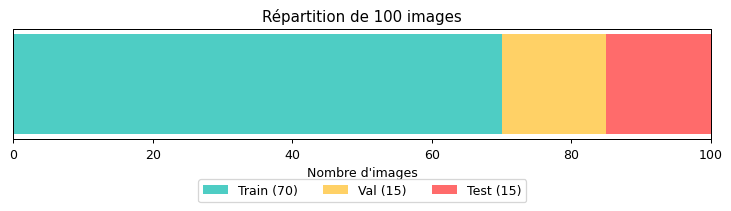

In [52]:
# 🔧 Vous pouvez modifier ces valeurs
TOTAL_IMAGES = 100
PCT_TRAIN = 70
PCT_VAL = 15
PCT_TEST = 100 - PCT_TRAIN - PCT_VAL

n_train = int(TOTAL_IMAGES * PCT_TRAIN / 100)
n_val   = int(TOTAL_IMAGES * PCT_VAL / 100)
n_test  = TOTAL_IMAGES - n_train - n_val

fig, ax = plt.subplots(figsize=(10, 1.6))
ax.barh(0, n_train,                             color="#4ECDC4", label=f"Train ({n_train})")
ax.barh(0, n_val,   left=n_train,               color="#FFD166", label=f"Val ({n_val})")
ax.barh(0, n_test,  left=n_train+n_val,         color="#FF6B6B", label=f"Test ({n_test})")
ax.set_xlim(0, TOTAL_IMAGES); ax.set_yticks([])
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=3)
ax.set_xlabel("Nombre d'images")
ax.set_title(f"Répartition de {TOTAL_IMAGES} images")
plt.show()

### 6.2 Le risque du sur-apprentissage (*overfitting*)

Si on **n'avait pas** de set de validation, on ne pourrait pas savoir si
le modèle **généralise** ou s'il a juste **mémorisé** les exemples
d'entraînement.

Voici à quoi ça ressemble en pratique :

/var/folders/x5/bcynmv8s67bczy9pg8gblp3m0000gp/T/ipykernel_72386/1974703017.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout(); plt.show()
/Users/chateau/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


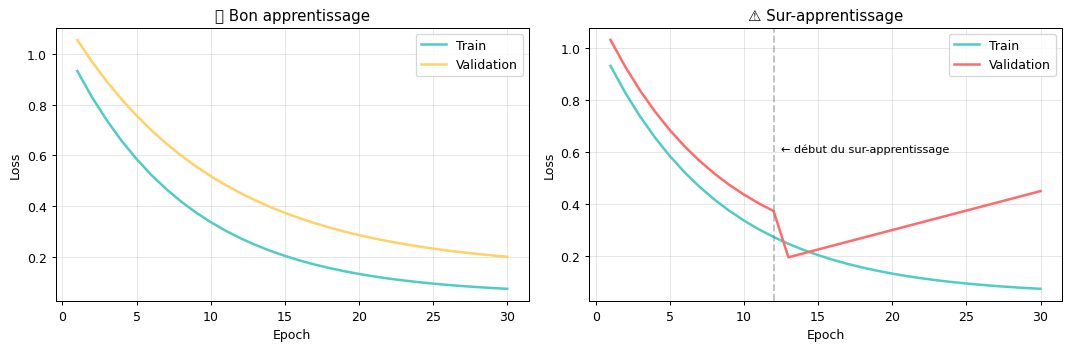

In [53]:
epochs = np.arange(1, 31)

# Scénario 1 : bon apprentissage
train_loss   = 1.0 * np.exp(-epochs / 8) + 0.05
val_loss_ok  = 1.0 * np.exp(-epochs / 10) + 0.15

# Scénario 2 : sur-apprentissage (val loss remonte après l'epoch 12)
val_loss_overfit = np.where(
    epochs <= 12,
    1.0 * np.exp(-epochs / 8) + 0.15,
    0.18 + 0.015 * (epochs - 12),
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss,  label="Train", color="#4ECDC4", linewidth=2)
ax1.plot(epochs, val_loss_ok, label="Validation", color="#FFD166", linewidth=2)
ax1.set_title("✅ Bon apprentissage")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, train_loss,        label="Train", color="#4ECDC4", linewidth=2)
ax2.plot(epochs, val_loss_overfit,  label="Validation", color="#FF6B6B", linewidth=2)
ax2.axvline(x=12, color="gray", linestyle="--", alpha=0.5)
ax2.text(12.5, 0.6, "← début du sur-apprentissage", fontsize=9)
ax2.set_title("⚠️ Sur-apprentissage")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

- **À gauche** : train et val baissent ensemble → patterns **généralisables** ✅
- **À droite** : la loss train continue de baisser mais la loss val
  **remonte**. Le modèle mémorise sans apprendre. ⚠️

### 🛡️ Les parades

- **Early stopping** : on arrête quand la loss val stagne (option
  `patience` dans YOLO — voir section 8)
- **Plus de données** : augmenter et diversifier
- **Data augmentation** : transformations aléatoires (rotations, flips,
  changements de couleur)
- **Régularisation** : pénaliser la complexité du modèle

**💡 Question** : sur la figure de droite, à quel epoch auriez-vous dû
arrêter l'entraînement ? Pourquoi ?

---
## 7. Epoch, batch et loss

Trois mots qui reviennent en permanence en deep learning. Démystifions-les.

### 7.1 Batch

Un **batch** (« lot ») est un **petit paquet d'images** que le modèle
traite ensemble avant de mettre à jour ses poids.

- **Trop petit** (batch=1) : mises à jour bruitées, apprentissage instable
- **Trop grand** (batch=128) : nécessite beaucoup de mémoire
- **Typique sur CPU** : 4 à 16

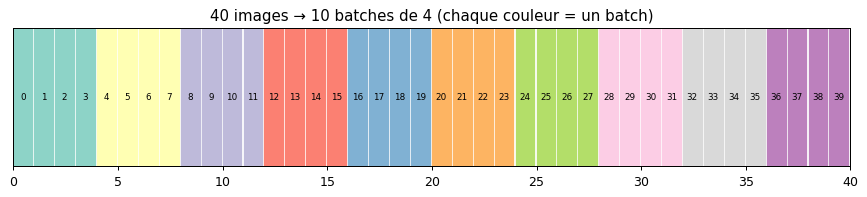

Avec batch_size=4 : 10 mises à jour de poids par epoch.


In [54]:
# Visualisons comment 40 images sont regroupées en batches
N_IMAGES = 40
BATCH_SIZE = 4  # 🔧 modifie cette valeur
n_batches = (N_IMAGES + BATCH_SIZE - 1) // BATCH_SIZE

fig, ax = plt.subplots(figsize=(12, 2))
for i in range(N_IMAGES):
    batch_idx = i // BATCH_SIZE
    color = plt.cm.Set3(batch_idx % 12)
    ax.add_patch(plt.Rectangle((i, 0), 0.9, 1, color=color))
    ax.text(i + 0.45, 0.5, str(i), ha="center", va="center", fontsize=7)
ax.set_xlim(0, N_IMAGES); ax.set_ylim(0, 1); ax.set_yticks([])
ax.set_title(f"{N_IMAGES} images → {n_batches} batches de {BATCH_SIZE} (chaque couleur = un batch)")
plt.show()

print(f"Avec batch_size={BATCH_SIZE} : {n_batches} mises à jour de poids par epoch.")

### 7.2 Epoch

Une **epoch** = **un passage complet** du modèle sur **toutes** les images
d'entraînement.

À chaque epoch, le modèle voit chaque image **une fois**. On enchaîne
plusieurs epochs (10, 30, 100…) jusqu'à ce que les performances arrêtent
de s'améliorer.

```python
for epoch in range(N_EPOCHS):
    for batch in train_dataloader:          # un epoch = parcourir TOUS les batches
        predictions = model(batch)          # forward pass
        loss = compute_loss(predictions, labels)
        update_weights(loss)                # backward pass
```

In [55]:
N_EPOCHS = 15
total_updates = N_EPOCHS * n_batches
print(f"{N_EPOCHS} epochs × {n_batches} batches = {total_updates} mises à jour de poids.")
print()
print("Chaque mise à jour ajuste légèrement les ~2,6 millions de paramètres de YOLO11n.")

15 epochs × 10 batches = 150 mises à jour de poids.

Chaque mise à jour ajuste légèrement les ~2,6 millions de paramètres de YOLO11n.


### 7.3 Loss (fonction de coût)

La **loss** est un **nombre qui mesure à quel point le modèle se trompe**.
Plus elle est petite, mieux c'est. L'entraînement consiste à modifier les
poids du modèle pour **faire descendre la loss**.

Pour la détection, YOLO combine **trois losses** :

- **box loss** — erreur sur les **coordonnées** des boîtes
- **class loss** — erreur sur la **classification** (rectangle vs cercle vs…)
- **DFL loss** (*Distribution Focal Loss*) — affinement de la localisation

$$\text{Loss totale} = \text{box\_loss} + \text{class\_loss} + \text{dfl\_loss}$$

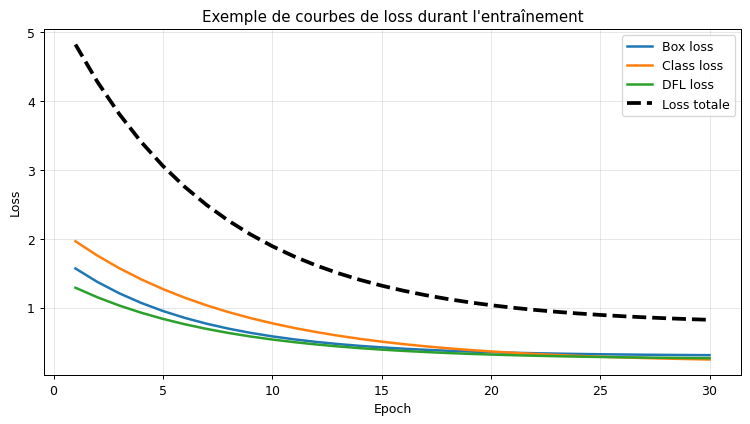

In [56]:
# Exemple typique de courbes de loss
epochs_arr = np.arange(1, 31)
box_loss = 1.5 * np.exp(-epochs_arr / 6) + 0.3
cls_loss = 2.0 * np.exp(-epochs_arr / 8) + 0.2
dfl_loss = 1.2 * np.exp(-epochs_arr / 7) + 0.25
total    = box_loss + cls_loss + dfl_loss

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_arr, box_loss, label="Box loss",   linewidth=2)
ax.plot(epochs_arr, cls_loss, label="Class loss", linewidth=2)
ax.plot(epochs_arr, dfl_loss, label="DFL loss",   linewidth=2)
ax.plot(epochs_arr, total,    label="Loss totale", linewidth=3, linestyle="--", color="black")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Exemple de courbes de loss durant l'entraînement")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

> 💡 **À retenir**
> - **Batch** = petit paquet d'images traitées ensemble
> - **Epoch** = un passage complet sur les données d'entraînement
> - **Loss** = score d'erreur qu'on cherche à minimiser

---
## 8. Entraînement du modèle

On va maintenant lancer un **vrai entraînement** sur la machine. On part
de **`yolo11n.pt`** — la plus petite variante YOLO disponible chez
Ultralytics — **pré-entraîné sur COCO** (80 classes d'objets courants).

### 8.1 L'apprentissage par transfert (*transfer learning*)

Le modèle pré-entraîné a déjà appris à reconnaître des contours, des
textures, des formes simples grâce à des millions d'images. On garde tout
ça et on ajuste seulement la **tête de détection** pour nos 3 classes
(rectangle, cercle, triangle).

C'est **beaucoup plus rapide** que d'entraîner depuis zéro.

In [57]:
# Import d'Ultralytics
from ultralytics import YOLO

# Chargement du modèle pré-entraîné
# (sera téléchargé automatiquement la première fois, ~5 MB)
model = YOLO(PRETRAINED_MODEL)

n_params = sum(p.numel() for p in model.model.parameters())
print(f"✓ Modèle {PRETRAINED_MODEL} chargé")
print(f"✓ Nombre de paramètres : {n_params / 1e6:.2f} M")
print(f"✓ Pré-entraîné sur COCO ({len(model.names)} classes)")

✓ Modèle yolo11n.pt chargé
✓ Nombre de paramètres : 2.62 M
✓ Pré-entraîné sur COCO (80 classes)


### 8.2 Paramètres d'entraînement

| Paramètre | Effet | Conseils |
|-----------|-------|----------|
| `epochs` | Nombre de passages sur le dataset | + = meilleur, mais plus long |
| `imgsz` | Taille des images | **Levier principal** sur le temps ! |
| `batch` | Taille du batch | Selon votre RAM (4 à 16) |
| `device` | CPU ou GPU | `cpu` ici (pas de GPU requis) |
| `patience` | Early stopping | Arrêt si pas d'amélioration |
| `workers` | Threads de chargement | 2 sur CPU |

⚠️ **Estimation de durée** : avec les valeurs par défaut ci-dessous
(imgsz=160, 15 epochs), comptez **~2 à 3 minutes** sur un CPU moderne.
Doublez `imgsz` → ×4 sur le temps.

In [58]:
# 🔧 Paramètres à modifier
TRAIN_EPOCHS = 15      # 15-30 typiquement
TRAIN_IMGSZ = 160      # 96, 128, 160, 224, 320, 416 (impact ×4 si doublé)
TRAIN_BATCH = 4        # 1 à 16
TRAIN_PATIENCE = 10    # Early stopping après N epochs sans progrès

# Estimation
sec_per_epoch = max(2, int((TRAIN_IMGSZ / 160) ** 2 * 6))
est_total = TRAIN_EPOCHS * sec_per_epoch
print(f"⏱️ Estimation : ~{est_total // 60} min {est_total % 60}s")
print(f"   ({TRAIN_EPOCHS} epochs × ~{sec_per_epoch}s/epoch à imgsz={TRAIN_IMGSZ})")

⏱️ Estimation : ~1 min 30s
   (15 epochs × ~6s/epoch à imgsz=160)


### 8.3 Lancement de l'entraînement

🚨 **La cellule suivante va prendre plusieurs minutes**. Pendant
l'exécution, vous verrez les barres de progression d'Ultralytics et les
métriques epoch par epoch.

In [59]:
results = model.train(
    data=str(DATASET_PATH / "data.yaml"),
    epochs=TRAIN_EPOCHS,
    imgsz=TRAIN_IMGSZ,
    batch=TRAIN_BATCH,
    device="cpu",
    workers=2,
    patience=TRAIN_PATIENCE,
    project=str(RUNS_PATH),
    name=RUN_NAME,
    exist_ok=True,
    verbose=True,
    plots=True,
)

print()
print(f"✅ Entraînement terminé !")
print(f"📁 Résultats sauvegardés dans : {results.save_dir}")

New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.8.11 torch-2.1.1 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/chateau/Enseignement/MachineLearning/DeepLearning/Tds/practical_yolo/mini_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=160, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mo

### 8.4 Analyse des résultats

YOLO génère automatiquement un fichier `results.png` qui résume tout
l'entraînement : courbes de loss, métriques epoch par epoch.

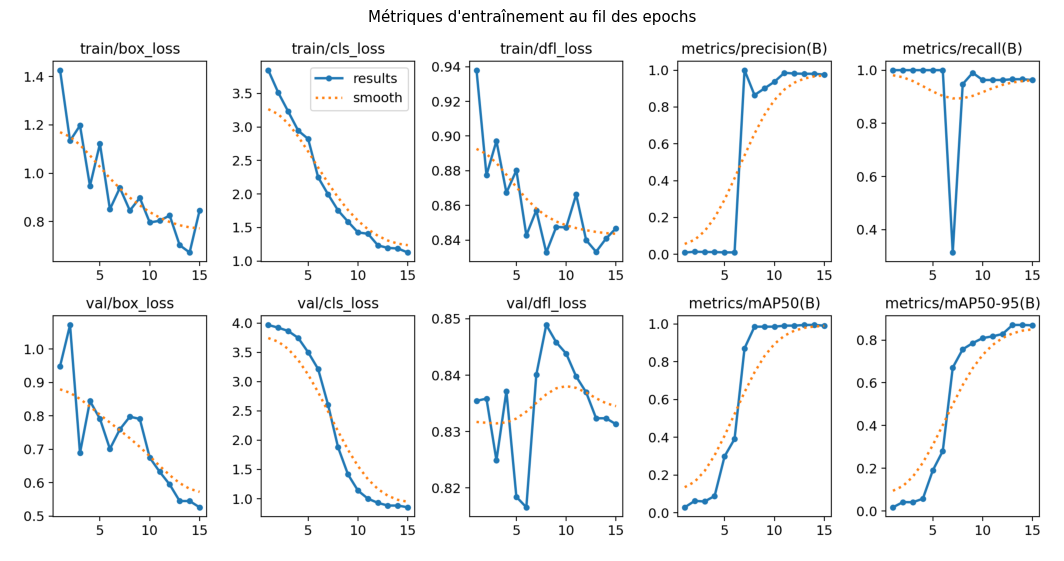

📊 À observer :
  - Les losses (box, cls, dfl) doivent DIMINUER
  - mAP50 et mAP50-95 doivent AUGMENTER
  - Les courbes de validation doivent suivre celles d'entraînement


In [60]:
results_dir = Path(results.save_dir)
results_png = results_dir / "results.png"

if results_png.exists():
    img = Image.open(results_png)
    fig, ax = plt.subplots(figsize=(15, 8))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title("Métriques d'entraînement au fil des epochs")
    plt.show()
    print("📊 À observer :")
    print("  - Les losses (box, cls, dfl) doivent DIMINUER")
    print("  - mAP50 et mAP50-95 doivent AUGMENTER")
    print("  - Les courbes de validation doivent suivre celles d'entraînement")
else:
    print("⚠️ results.png introuvable")

---
## 9. Métriques d'évaluation

Comment savoir si un détecteur est **bon** ? On utilise plusieurs
métriques complémentaires.

### 9.1 IoU — Intersection over Union

L'**IoU** mesure le **recouvrement** entre une boîte prédite et la
vérité terrain :

$$IoU = \frac{\text{Aire d'intersection}}{\text{Aire d'union}}$$

- IoU = 0 : aucun recouvrement
- IoU = 1 : recouvrement parfait
- On considère souvent **IoU > 0,5** comme une « bonne » détection

/Users/chateau/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chateau/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


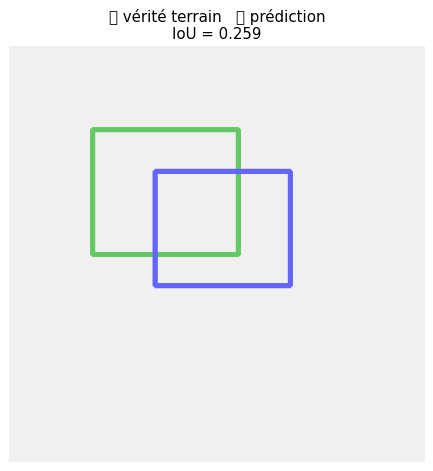

IoU = 0.2591
⚠️ Détection insuffisante


In [61]:
def compute_iou(box1, box2):
    '''IoU entre deux boîtes au format (x1, y1, x2, y2).'''
    # Intersection : on prend le rectangle commun
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    # Pas de recouvrement
    if x2 <= x1 or y2 <= y1:
        return 0.0
    inter = (x2 - x1) * (y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    return inter / union


# Test avec deux boîtes
gt   = (80, 80, 220, 200)   # vérité terrain (x1, y1, x2, y2)
pred = (140, 120, 270, 230) # prédiction
iou_val = compute_iou(gt, pred)

# Visualisons
fig, ax = plt.subplots(figsize=(6, 6))
canvas = np.ones((400, 400, 3), dtype=np.uint8) * 240
cv2.rectangle(canvas, (gt[0],   gt[1]),   (gt[2],   gt[3]),   (100, 200, 100), 3)
cv2.rectangle(canvas, (pred[0], pred[1]), (pred[2], pred[3]), (100, 100, 255), 3)
ax.imshow(canvas)
ax.set_title(f"🟢 vérité terrain   🔵 prédiction\nIoU = {iou_val:.3f}")
ax.axis('off')
plt.show()

print(f"IoU = {iou_val:.4f}")
if iou_val > 0.7:
    print("✅ Excellente détection")
elif iou_val > 0.5:
    print("👍 Détection acceptable")
elif iou_val > 0:
    print("⚠️ Détection insuffisante")
else:
    print("❌ Aucun recouvrement")

**🔧 À toi de jouer** : modifie les valeurs de `gt` et `pred` ci-dessus
pour explorer différents cas. Essaie notamment :
- les **mêmes** coordonnées → IoU = 1
- des boîtes **disjointes** → IoU = 0
- une petite boîte **incluse** dans une grande

### 9.2 Précision et Rappel

Une fois qu'on a décidé qu'une boîte est « correcte » (IoU > seuil), on
compte :

- **Vrais positifs (VP)** : objets correctement détectés
- **Faux positifs (FP)** : détections qui ne correspondent à aucun objet
- **Faux négatifs (FN)** : objets ratés (pas détectés)

$$\text{Précision} = \frac{VP}{VP + FP} \quad \text{(parmi mes détections, combien sont correctes ?)}$$

$$\text{Rappel} = \frac{VP}{VP + FN} \quad \text{(parmi les vrais objets, combien ai-je trouvés ?)}$$

In [62]:
# 🔧 Exemple numérique
VP = 8
FP = 2
FN = 1

precision = VP / (VP + FP)
recall    = VP / (VP + FN)
f1        = 2 * precision * recall / (precision + recall)

print(f"VP={VP}, FP={FP}, FN={FN}")
print(f"  → Précision = {VP}/{VP+FP} = {precision:.3f}  ({precision*100:.1f}% de mes détections sont correctes)")
print(f"  → Rappel    = {VP}/{VP+FN} = {recall:.3f}  ({recall*100:.1f}% des objets ont été trouvés)")
print(f"  → F1-score  = {f1:.3f}     (moyenne harmonique)")

VP=8, FP=2, FN=1
  → Précision = 8/10 = 0.800  (80.0% de mes détections sont correctes)
  → Rappel    = 8/9 = 0.889  (88.9% des objets ont été trouvés)
  → F1-score  = 0.842     (moyenne harmonique)


### ⚖️ Le compromis précision / rappel

- Si on **baisse le seuil de confiance** → plus de détections → souvent
  **plus de rappel** mais **moins de précision** (on prend tout, on se
  trompe plus).
- Si on **monte le seuil** → moins de détections → **plus de précision**
  mais **moins de rappel** (on ne garde que les détections très sûres).

### 9.3 mAP — Mean Average Precision

La **mAP** est **la métrique reine** de la détection. Elle combine
précision et rappel sur **tous les seuils de confiance** possibles,
moyennés sur **toutes les classes**.

- **mAP@50** : moyenne avec un seuil IoU de **0,5**
- **mAP@50-95** : moyenne sur 10 seuils IoU de 0,5 à 0,95 (par pas de 0,05),
  c'est la métrique principale de COCO, plus exigeante

| mAP50 | Qualité |
|-------|---------|
| > 0,9 | 🥇 excellent |
| 0,7 – 0,9 | 🥈 très bon |
| 0,5 – 0,7 | 🥉 correct |
| < 0,5 | 🔧 à améliorer |

### 9.4 Évaluation de notre modèle entraîné

In [ ]:
# Charger le meilleur modèle (sauvegardé automatiquement par YOLO)
best_weights = Path(results.save_dir) / "weights" / "best.pt"
print(f"Chargement de : {best_weights}")
best_model = YOLO(best_weights)

# Évaluer sur le set de validation
metrics = best_model.val(data=str(DATASET_PATH / "data.yaml"), device="cpu")

print()
print("📊 Métriques de validation :")
print(f"  mAP50      : {metrics.box.map50:.3f}   (objectif > 0.5)")
print(f"  mAP50-95   : {metrics.box.map:.3f}   (plus exigeant)")
print(f"  Précision  : {metrics.box.mp:.3f}")
print(f"  Rappel     : {metrics.box.mr:.3f}")

Chargement de : /Users/chateau/Enseignement/MachineLearning/DeepLearning/Tds/practical_yolo/yolo_finetuning/shape_detector_atelier/weights/best.pt
Ultralytics 8.4.14 🚀 Python-3.8.11 torch-2.1.1 CPU (Apple M2)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 172.0±19.8 MB/s, size: 3.5 KB)
val: Scanning /Users/chateau/Enseignement/MachineLearning/DeepLearning/Tds/practical_yolo/mini_dataset/labels/val.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 4.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 22.0it/s 0.0s


---
## 10. Inférence sur de nouvelles images

L'**inférence**, c'est l'étape où on **utilise** le modèle entraîné pour
détecter des objets sur de nouvelles images.

### Paramètres clés

- **`conf`** — seuil de confiance (0 à 1). Plus bas → plus de détections
  (et plus de faux positifs)
- **`iou`** — seuil pour la NMS (Non-Maximum Suppression), qui fusionne
  les boîtes qui se chevauchent trop

In [31]:
# 🔧 Paramètres à modifier
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.45

# Choisir une image de validation
val_images = sorted((DATASET_PATH / "images" / "val").glob("*.jpg"))
test_img_path = val_images[0]
print(f"Inférence sur : {test_img_path.name}")

results_pred = best_model.predict(
    source=str(test_img_path),
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    device="cpu",
    verbose=False,
)

result = results_pred[0]
print(f"\n🎯 {len(result.boxes)} objet(s) détecté(s) :")
for i, box in enumerate(result.boxes):
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    coords = box.xyxy[0].tolist()
    print(f"  {i+1}. {CLASS_NAMES[cls]:10s} confiance={conf:.3f}  "
          f"bbox=[{coords[0]:.0f}, {coords[1]:.0f}, {coords[2]:.0f}, {coords[3]:.0f}]")

Inférence sur : img_000.jpg

🎯 1 objet(s) détecté(s) :
  1. cercle     confiance=0.994  bbox=[212, 152, 276, 215]


### Visualisation des prédictions

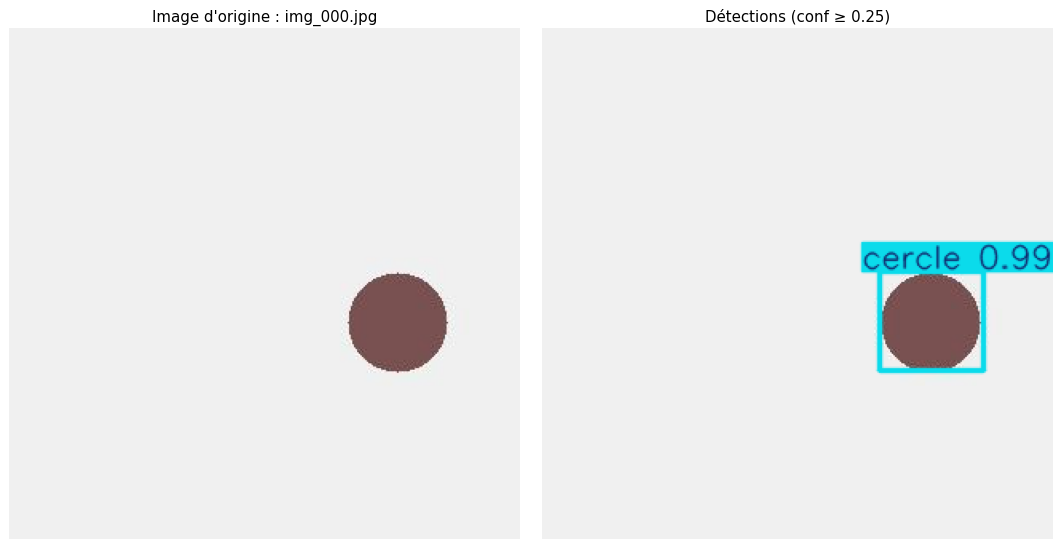

In [32]:
# Image d'origine vs image avec détections
original = np.array(Image.open(test_img_path))
annotated = result.plot()[:, :, ::-1]  # BGR -> RGB

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(original); ax1.set_title(f"Image d'origine : {test_img_path.name}"); ax1.axis('off')
ax2.imshow(annotated); ax2.set_title(f"Détections (conf ≥ {CONF_THRESHOLD})"); ax2.axis('off')
plt.tight_layout(); plt.show()

### Inférence sur plusieurs images d'un coup

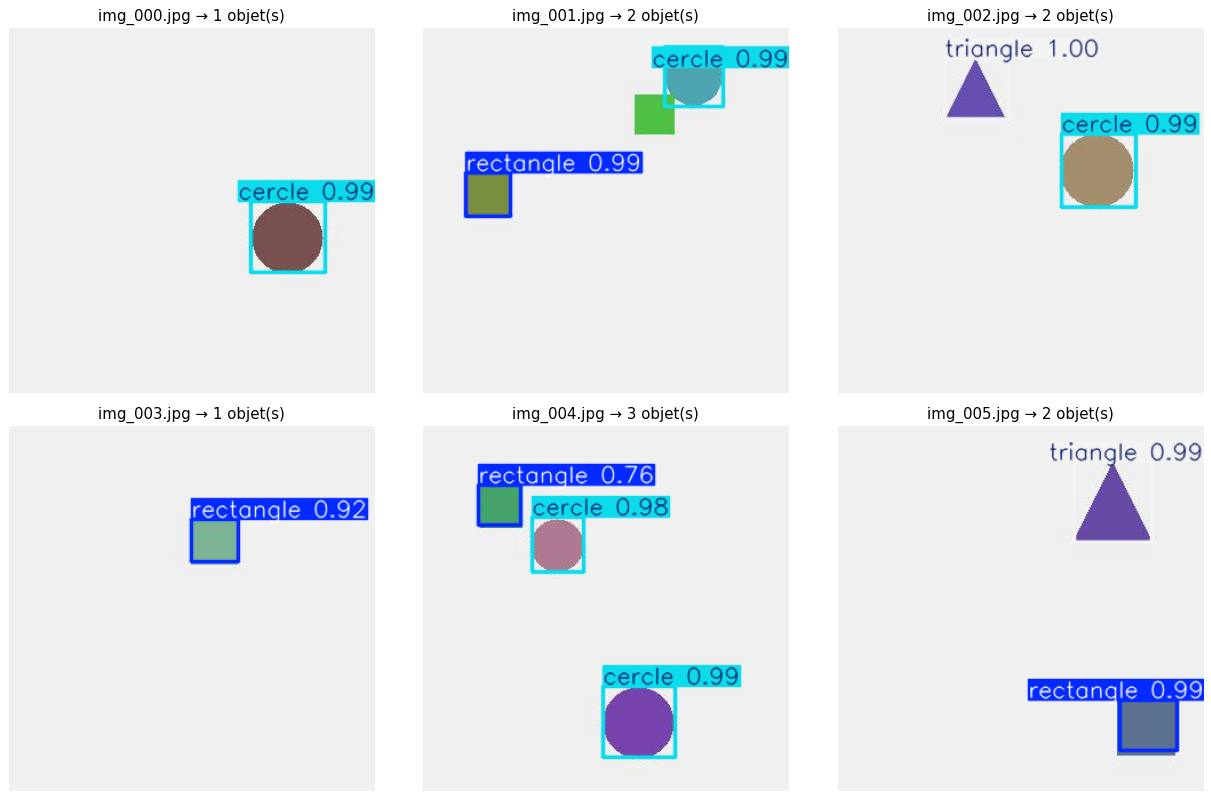

In [33]:
# Prédisons sur les 6 premières images de validation
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, img_path in zip(axes.ravel(), val_images[:6]):
    res = best_model.predict(source=str(img_path), conf=CONF_THRESHOLD,
                              iou=IOU_THRESHOLD, device="cpu", verbose=False)[0]
    ax.imshow(res.plot()[:, :, ::-1])
    ax.set_title(f"{img_path.name} → {len(res.boxes)} objet(s)")
    ax.axis('off')
plt.tight_layout(); plt.show()

### 🔧 À toi de jouer

**Idées d'expériences** :

1. **Baissez** `CONF_THRESHOLD` à 0.05 et observez : voyez-vous apparaître
   des **faux positifs** ?
2. **Montez** `CONF_THRESHOLD` à 0.9 et observez : combien d'objets sont
   **ratés** ?
3. **Générez une image** avec des paramètres extrêmes (très petits objets,
   beaucoup d'objets) et voyez comment le modèle réagit :

```python
img, _ = make_synthetic_image(seed=9999, n_objects_range=(6, 10))
plt.imshow(img); plt.show()
# Sauvegarder pour l'inférence
Image.fromarray(img).save("test_hard.jpg")
res = best_model.predict("test_hard.jpg", conf=0.2)[0]
plt.imshow(res.plot()[:, :, ::-1]); plt.show()
```

4. **Testez sur une vraie photo** : prenez une photo d'un cercle (assiette,
   pièce…), enregistrez-la et lancez l'inférence. Le modèle, entraîné
   uniquement sur des formes synthétiques, généralisera-t-il ?

---
## 11. Récapitulatif

Bravo, vous avez parcouru toutes les étapes du **fine-tuning** d'un
détecteur d'objets YOLO ! 🎉

### ✅ Ce que vous avez vu

| Étape | Concept clé |
|-------|-------------|
| 1 — Détection d'objets | Quoi **et** où, plusieurs objets par image |
| 2 — CNN | Convolution, filtres appris, pooling, hiérarchie de caractéristiques |
| 3 — Principe YOLO | Une seule passe, grille de prédiction, très rapide |
| 4 — Dataset | Images + labels au format YOLO |
| 5 — Labels | `class_id xc yc w h` normalisés entre 0 et 1 |
| 6 — Train / Val / Test | Mesurer la généralisation, éviter le sur-apprentissage |
| 7 — Epoch / Batch / Loss | La mécanique de l'apprentissage |
| 8 — Fine-tuning | Partir d'un modèle pré-entraîné, l'adapter à nos classes |
| 9 — Métriques | IoU, précision, rappel, mAP |
| 10 — Inférence | Utiliser le modèle entraîné sur de nouvelles images |

### 🎯 Exercices pour aller plus loin

#### Exercice 1 — Ajouter une 4ᵉ classe

Modifiez la fonction `draw_shape` pour ajouter une **étoile** (classe 3),
puis :
1. Régénérez le dataset
2. Mettez à jour `data.yaml`
3. Ré-entraînez
4. Évaluez : la nouvelle classe est-elle aussi bien détectée que les
   autres ? Pourquoi ?

#### Exercice 2 — Augmentation de données

Ultralytics applique de la data augmentation automatiquement. Cherchez
les paramètres `hsv_h`, `hsv_s`, `hsv_v`, `degrees`, `flipud`, `fliplr`
dans la documentation, et essayez de les modifier dans `model.train()`.

#### Exercice 3 — Comparer les modèles

Lancez le même entraînement avec `yolov8n.pt` au lieu de `yolo11n.pt`.
Quel est plus rapide ? Lequel donne la meilleure mAP ?

#### Exercice 4 — Détection sur une vraie photo

Prenez 5 photos d'objets ronds (assiettes, pièces, ballons…) avec votre
téléphone, mettez-les dans un dossier, et lancez l'inférence avec votre
modèle. Que constate-t-on ? Pourquoi ?

#### Exercice 5 — Annotation manuelle

Téléchargez [LabelImg](https://github.com/tzutalin/labelImg), annotez 20
photos d'un objet de votre choix, puis fine-tunez un modèle dessus. Vous
aurez alors fait un vrai projet de bout en bout.

### 📚 Ressources

- 📖 [Documentation officielle Ultralytics](https://docs.ultralytics.com/)
- 📄 [Article original YOLO (2015)](https://arxiv.org/abs/1506.02640)
- 🛠️ [Roboflow](https://roboflow.com/) — annotation et gestion de datasets
- 💬 [Forum communautaire Ultralytics](https://github.com/ultralytics/ultralytics/discussions)

---

**Bon courage pour vos projets de vision par ordinateur ! 🚀**
